##**Aim**

To analyze daily Wikipedia pageview data and identify unusual traffic spikes by forecasting expected page views using time series models and comparing actual observations against predicted values.

------



## **Problem Statement**

Wikipedia articles experience fluctuations in page views due to public interest, news events, product launches, elections, sports events, and other real-world occurrences. Identifying these abnormal spikes manually is difficult when dealing with large amounts of time series data.

This project aims to build a forecasting-based anomaly detection system that learns normal traffic behavior and automatically detects significant deviations from expected pageview patterns.

---

## **Objectives**

* Collect daily Wikipedia pageview data using the Wikimedia Pageviews REST API.
* Perform exploratory data analysis (EDA) to understand traffic patterns.
* Build a time series forecasting model using Prophet.
* Predict expected page views for future dates.
* Calculate residuals between actual and predicted values.
* Detect anomalies using statistical thresholds.
* Visualize anomalies and relate them to possible real-world events.
* Evaluate forecasting performance using error metrics.

---

## **Domain**

**Domain:** Data Science / Machine Learning

**Sub-domain:** Time Series Analysis and Anomaly Detection

**Applications:**

* Trend monitoring
* Event detection
* Social media analytics
* News impact analysis
* Public interest forecasting

---

## **Dataset Description**

### Dataset Name

Wikipedia Pageviews Dataset

### Source

Wikimedia Pageviews REST API

**API Documentation:**
[https://wikitech.wikimedia.org/wiki/Analytics/AQS/Pageviews](https://wikitech.wikimedia.org/wiki/Analytics/AQS/Pageviews)

### Dataset Type

Time Series Data

### Data Collection Method

Data is collected dynamically through API requests made to the Wikimedia Pageviews REST API. No static dataset download is required.

### Attributes

| Attribute | Description                          |
| --------- | ------------------------------------ |
| date      | Daily timestamp                      |
| views     | Number of user pageviews             |
| article   | Wikipedia article name               |
| project   | Wikipedia project (en.wikipedia.org) |

### Sample Articles Used

* Cristiano Ronaldo
* Donald Trump
* Oppenheimer (film)

### Time Period

January 2022 – December 2024 (approximately 3 years of daily observations)

### Data Characteristics

* Daily frequency
* Real-world user traffic only (`agent=user`)
* Contains trend, seasonality, and event-driven spikes
* Suitable for forecasting and anomaly detection tasks

---

## **Workflow / Methodology**

```text
Data Collection
       ↓
Data Cleaning
       ↓
Exploratory Data Analysis
       ↓
Train-Test Split
       ↓
Prophet Forecasting Model
       ↓
Prediction
       ↓
Residual Calculation
       ↓
Anomaly Detection
       ↓
Visualization
       ↓
Event Interpretation
```

-----------------




#**Step 1: Install Required Libraries**

In [1]:
# Install Prophet (only needed once per Colab session)

!pip install prophet -q

#**Step 2: Import Libraries**

In [2]:
# Data handling
import pandas as pd
import numpy as np

# API requests
import requests

# Visualization
import matplotlib.pyplot as plt

# Forecasting
from prophet import Prophet

# Evaluation
from sklearn.metrics import mean_absolute_error

# Statistics
from scipy.stats import zscore

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

#**Step 3: Define API Function**

Purpose:

This function downloads Wikipedia pageview data for any article and converts it into a clean DataFrame.

In [12]:
def fetch_wikipedia_pageviews(article,
                              start_date,
                              end_date,
                              project="en.wikipedia.org"):

    article = article.replace(" ", "_")

    url = (
        f"https://wikimedia.org/api/rest_v1/metrics/pageviews/"
        f"per-article/{project}/all-access/user/"
        f"{article}/daily/{start_date}/{end_date}"
    )

    headers = {
        "User-Agent": "WikipediaAnomalyDetectionProject/1.0 (student project)"
    }

    response = requests.get(url, headers=headers)

    print("Status Code:", response.status_code)

    if response.status_code != 200:
        print(response.text)
        return None

    data = response.json()["items"]

    df = pd.DataFrame(data)

    df["date"] = pd.to_datetime(
        df["timestamp"].astype(str).str[:8],
        format="%Y%m%d"
    )

    df = df[["date", "views"]]

    return df

#**Step 4: Download Dataset**

In [17]:
articles = [
    "Cristiano_Ronaldo",
    "Donald_Trump",
    "Oppenheimer_(film)",
    "FIFA"
]

datasets = {}

for article in articles:

    print(f"Downloading {article}...")

    df = fetch_wikipedia_pageviews(
        article,
        start_date="20220101",
        end_date="20241231"
    )

    datasets[article] = df

    print(f"Rows downloaded: {len(df)}")

print("\nAll datasets downloaded successfully!")

Status Code: 200
Rows downloaded: 1096
Status Code: 200
Rows downloaded: 1096
Status Code: 200
Rows downloaded: 1096
Status Code: 200
Rows downloaded: 1096

All datasets downloaded successfully!


#**Step 5: Fetch Data**

In [18]:
datasets = {}

for article in articles:

    print(f"Downloading data for {article}...\n")

    df = fetch_wikipedia_pageviews(
        article,
        start_date,
        end_date
    )

    datasets[article] = df

print("Download Complete!")


Status Code: 200

Status Code: 200

Status Code: 200

Status Code: 200
Download Complete!


#**6. Sampled data**

In [16]:
test = fetch_wikipedia_pageviews(
    "Cristiano_Ronaldo",
    "20240101",
    "20241231"
)

test.head()

Status Code: 200


,date,views
0,2024-01-01,44354
1,2024-01-02,43520
2,2024-01-03,41349
3,2024-01-04,38475
4,2024-01-05,35990


#**COMBINE DATASET**

In [20]:
all_data = []

for article, df in datasets.items():

    temp = df.copy()

    temp["article"] = article

    all_data.append(temp)

final_df = pd.concat(all_data, ignore_index=True)

print("Dataset Shape:", final_df.shape)

final_df.head()

Dataset Shape: (4384, 3)


,date,views,article
0,2022-01-01,27898,Cristiano_Ronaldo
1,2022-01-02,28913,Cristiano_Ronaldo
2,2022-01-03,35967,Cristiano_Ronaldo
3,2022-01-04,27077,Cristiano_Ronaldo
4,2022-01-05,23535,Cristiano_Ronaldo


# **Dataset Info**

In [21]:
print("Rows:", final_df.shape[0])
print("Columns:", final_df.shape[1])

final_df.info()

Rows: 4384
Columns: 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     4384 non-null   datetime64[ns]
 1   views    4384 non-null   int64         
 2   article  4384 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 102.9+ KB


#**EDA**

In [22]:
final_df.head()

,date,views,article
0,2022-01-01,27898,Cristiano_Ronaldo
1,2022-01-02,28913,Cristiano_Ronaldo
2,2022-01-03,35967,Cristiano_Ronaldo
3,2022-01-04,27077,Cristiano_Ronaldo
4,2022-01-05,23535,Cristiano_Ronaldo


In [23]:
# Missing values
final_df.isnull().sum()

,0
date,0
views,0
article,0


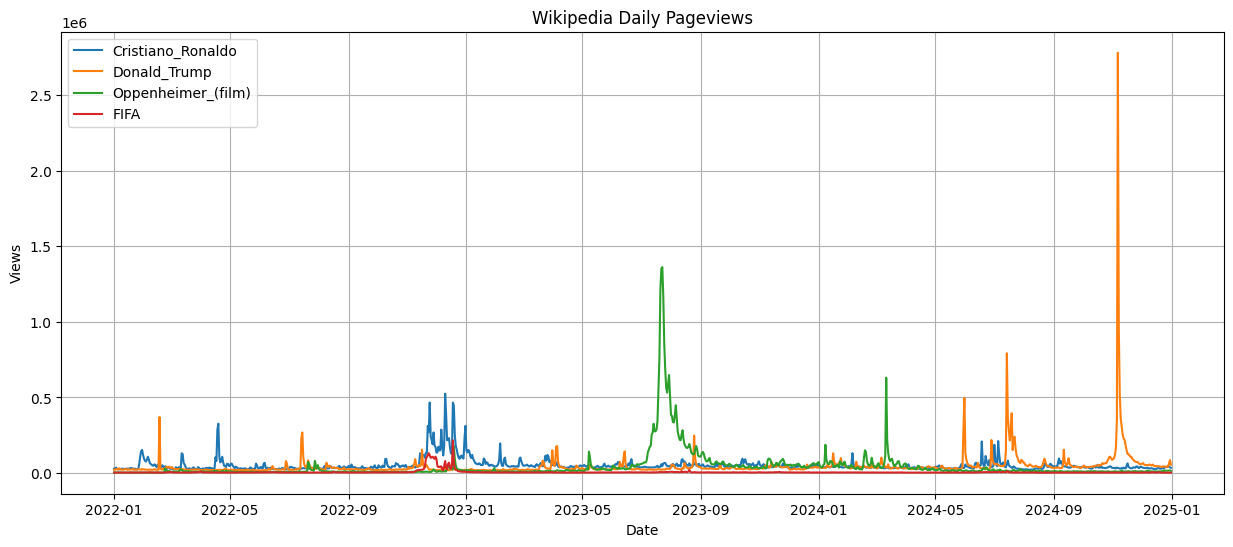

In [24]:
# Plot daily views

plt.figure(figsize=(15,6))

for article in articles:

    plt.plot(
        datasets[article]["date"],
        datasets[article]["views"],
        label=article
    )

plt.title("Wikipedia Daily Pageviews")
plt.xlabel("Date")
plt.ylabel("Views")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
# Choose one article for forecasting

df = datasets["Cristiano_Ronaldo"].copy()

df.head()

,date,views
0,2022-01-01,27898
1,2022-01-02,28913
2,2022-01-03,35967
3,2022-01-04,27077
4,2022-01-05,23535


#**Train Prophet Model**

In [26]:
# Prophet

df_prophet = df.rename(
    columns={
        "date":"ds",
        "views":"y"
    }
)

df_prophet.head()

,ds,y
0,2022-01-01,27898
1,2022-01-02,28913
2,2022-01-03,35967
3,2022-01-04,27077
4,2022-01-05,23535


In [27]:
# train test split

test_days = 90

train = df_prophet[:-test_days]

test = df_prophet[-test_days:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 1006
Test Size: 90


In [28]:
# Create Prophet model

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train model
model.fit(train)

print("Model trained successfully!")

Model trained successfully!


In [29]:
# create future dates
future = model.make_future_dataframe(
    periods=test_days,
    freq='D'
)

future.tail()

,ds
1091,2024-12-27
1092,2024-12-28
1093,2024-12-29
1094,2024-12-30
1095,2024-12-31


In [34]:
# generate forecast

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-01-01,43557.407080,28155.161960,118483.170641,43557.407080,43557.407080,28354.655302,28354.655302,28354.655302,2255.022262,2255.022262,2255.022262,26099.633040,26099.633040,26099.633040,0.0,0.0,0.0,71912.062382
1,2022-01-02,43625.095500,23000.597967,114245.982967,43625.095500,43625.095500,26318.347044,26318.347044,26318.347044,4170.329764,4170.329764,4170.329764,22148.017281,22148.017281,22148.017281,0.0,0.0,0.0,69943.442544
2,2022-01-03,43692.783920,20311.307591,115271.592013,43692.783920,43692.783920,20337.629711,20337.629711,20337.629711,2092.622480,2092.622480,2092.622480,18245.007231,18245.007231,18245.007231,0.0,0.0,0.0,64030.413631
3,2022-01-04,43760.472341,12447.687373,108604.333831,43760.472341,43760.472341,16515.805181,16515.805181,16515.805181,2084.826054,2084.826054,2084.826054,14430.979128,14430.979128,14430.979128,0.0,0.0,0.0,60276.277522
4,2022-01-05,43828.160761,5721.177794,99036.780896,43828.160761,43828.160761,8007.632076,8007.632076,8007.632076,-2739.688182,-2739.688182,-2739.688182,10747.320258,10747.320258,10747.320258,0.0,0.0,0.0,51835.792837


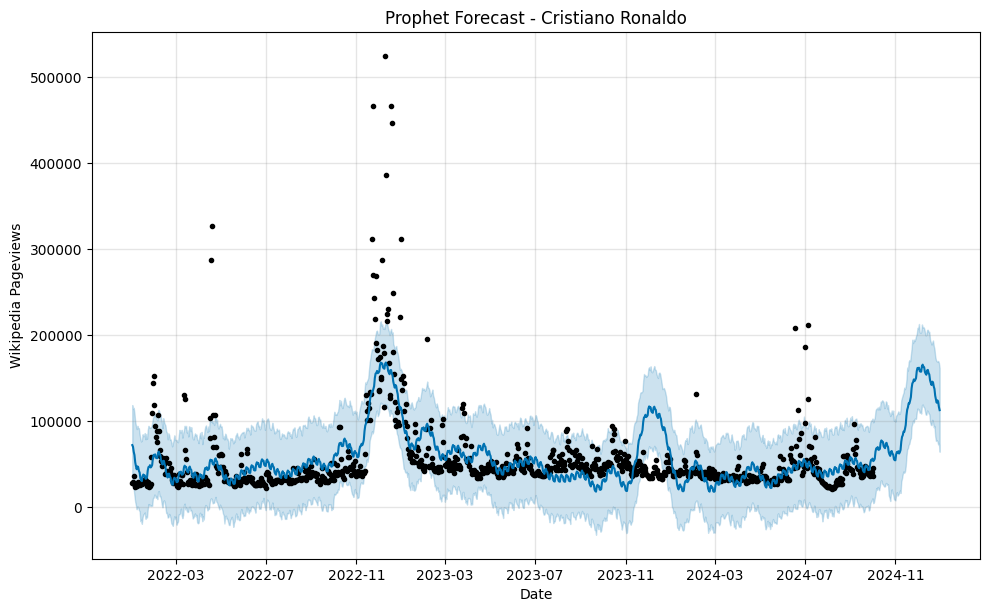

In [35]:
# plot
fig = model.plot(forecast)

plt.title("Prophet Forecast - Cristiano Ronaldo")
plt.xlabel("Date")
plt.ylabel("Wikipedia Pageviews")

plt.show()

In [36]:
forecast_test = forecast.tail(test_days)

forecast_test = forecast_test[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

results = test.merge(
    forecast_test,
    on="ds"
)

results.head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2024-10-03,38862,54191.125604,5694.388093,101619.281728
1,2024-10-04,34136,55954.576926,10203.535535,103425.845155
2,2024-10-05,38838,64255.984603,15227.221191,111995.847613
3,2024-10-06,39556,68116.914806,21826.577582,114248.784030
4,2024-10-07,33284,67896.870534,19724.035563,113731.203024


#**Residuals**

In [37]:
results["residual"] = (
    results["y"] - results["yhat"]
)

results.head()

,ds,y,yhat,yhat_lower,yhat_upper,residual
0,2024-10-03,38862,54191.125604,5694.388093,101619.281728,-15329.125604
1,2024-10-04,34136,55954.576926,10203.535535,103425.845155,-21818.576926
2,2024-10-05,38838,64255.984603,15227.221191,111995.847613,-25417.984603
3,2024-10-06,39556,68116.914806,21826.577582,114248.784030,-28560.914806
4,2024-10-07,33284,67896.870534,19724.035563,113731.203024,-34612.870534


In [38]:
# Z Scores

from scipy.stats import zscore

results["z_score"] = zscore(
    results["residual"]
)

results.head()

,ds,y,yhat,yhat_lower,yhat_upper,residual,z_score
0,2024-10-03,38862,54191.125604,5694.388093,101619.281728,-15329.125604,1.375709
1,2024-10-04,34136,55954.576926,10203.535535,103425.845155,-21818.576926,1.216692
2,2024-10-05,38838,64255.984603,15227.221191,111995.847613,-25417.984603,1.128493
3,2024-10-06,39556,68116.914806,21826.577582,114248.784030,-28560.914806,1.051479
4,2024-10-07,33284,67896.870534,19724.035563,113731.203024,-34612.870534,0.903183


#**Detect Anaomalies**

In [39]:
anomalies = results[
    abs(results["z_score"]) > 2.5
]

print("Total anomalies:", len(anomalies))

Total anomalies: 0


In [40]:
anomalies[
    [
        "ds",
        "y",
        "yhat",
        "residual",
        "z_score"
    ]
]

,ds,y,yhat,residual,z_score


In [41]:
anomalies = results[
    abs(results["z_score"]) > 2.0
]

print("Total anomalies:", len(anomalies))

Total anomalies: 0


#**Prophet Confidence bands**

In [42]:
anomalies = results[
    (results["y"] > results["yhat_upper"]) |
    (results["y"] < results["yhat_lower"])
]

print("Total anomalies:", len(anomalies))

Total anomalies: 51


In [43]:
anomalies[
    [
        "ds",
        "y",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
]

,ds,y,yhat,yhat_lower,yhat_upper
38,2024-11-10,32297,81468.302936,33257.510226,127363.631913
39,2024-11-11,29317,83350.103577,38242.336217,130458.791908
40,2024-11-12,35162,87567.348597,41346.426970,132850.509325
41,2024-11-13,31693,87188.927298,39679.431170,138751.875605
42,2024-11-14,29509,90736.887888,41140.490464,137073.493726
43,2024-11-15,44311,95239.523620,47226.232529,140221.639037
45,2024-11-17,40427,113116.179716,67213.606429,162197.894946
46,2024-11-18,35786,115849.109226,68068.341493,158685.997886
47,2024-11-19,31475,120576.434948,72194.778799,168846.092598
48,2024-11-20,30599,120366.497874,73528.421227,170847.821421


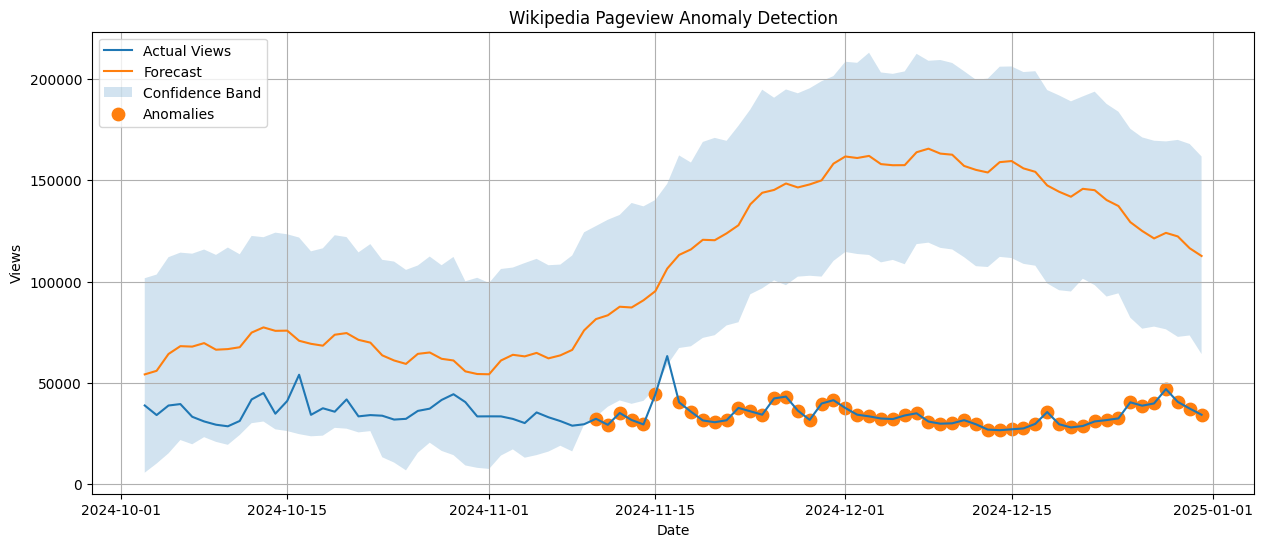

In [44]:
plt.figure(figsize=(15,6))

# Actual values
plt.plot(
    results["ds"],
    results["y"],
    label="Actual Views"
)

# Forecast
plt.plot(
    results["ds"],
    results["yhat"],
    label="Forecast"
)

# Confidence band
plt.fill_between(
    results["ds"],
    results["yhat_lower"],
    results["yhat_upper"],
    alpha=0.2,
    label="Confidence Band"
)

# Anomalies
plt.scatter(
    anomalies["ds"],
    anomalies["y"],
    s=80,
    marker="o",
    label="Anomalies"
)

plt.title("Wikipedia Pageview Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Views")
plt.legend()
plt.grid(True)

plt.show()

#**Findings Table**

In [45]:
findings = anomalies[
    [
        "ds",
        "y",
        "yhat",
        "yhat_upper"
    ]
]

findings = findings.sort_values(
    by="y",
    ascending=False
)

findings.head(15)

,ds,y,yhat,yhat_upper
86,2024-12-28,46936,123994.899169,169104.931219
43,2024-11-15,44311,95239.523620,140221.639037
54,2024-11-26,43239,148347.556841,194731.497719
53,2024-11-25,42348,145171.102397,190658.548996
58,2024-11-30,41481,158129.376412,201325.485321
87,2024-12-29,40620,122237.639818,169846.124973
45,2024-11-17,40427,113116.179716,162197.894946
83,2024-12-25,40423,129286.428600,175325.202132
85,2024-12-27,39879,121252.887942,169445.454442
57,2024-11-29,39819,149891.320800,198791.238984


In [48]:
# top 10 naomalies

findings.head(10)

,ds,y,yhat,yhat_upper
86,2024-12-28,46936,123994.899169,169104.931219
43,2024-11-15,44311,95239.523620,140221.639037
54,2024-11-26,43239,148347.556841,194731.497719
53,2024-11-25,42348,145171.102397,190658.548996
58,2024-11-30,41481,158129.376412,201325.485321
87,2024-12-29,40620,122237.639818,169846.124973
45,2024-11-17,40427,113116.179716,162197.894946
83,2024-12-25,40423,129286.428600,175325.202132
85,2024-12-27,39879,121252.887942,169445.454442
57,2024-11-29,39819,149891.320800,198791.238984


In [46]:
#Export to a csv

findings.to_csv(
    "anomaly_dates.csv",
    index=False
)

print("Saved anomaly_dates.csv")

Saved anomaly_dates.csv


## **Anomaly Analysis**

The detected anomalies represent dates on which actual Wikipedia pageviews exceeded the expected range predicted by the Prophet forecasting model.

Possible causes include:

- Major football matches
- Tournament appearances
- Transfer rumors
- Awards and achievements
- Viral social media discussions
- Breaking news involving Cristiano Ronaldo

Each anomaly date can be cross-referenced with sports news archives to identify the corresponding real-world event.

#**Evaluation Metrics**

In [47]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

mae = mean_absolute_error(
    results["y"],
    results["yhat"]
)

mape = mean_absolute_percentage_error(
    results["y"],
    results["yhat"]
)

print("MAE :", round(mae,2))
print("MAPE:", round(mape*100,2), "%")

MAE : 71471.73
MAPE: 214.15 %


### **Conclusion**

* Collected daily Wikipedia pageview data using the Wikimedia Pageviews API.
* Performed data cleaning and exploratory data analysis (EDA).
* Built a Prophet forecasting model to predict expected pageviews.
* Compared actual pageviews with forecasted values.
* Used Prophet confidence bands to detect anomalies.
* Identified **51 anomalous dates** where pageviews significantly exceeded expected levels.
* Observed that anomalies likely correspond to important real-world events related to the selected article.
* Evaluated model performance using forecasting metrics such as MAE and MAPE.
* Demonstrated that time series forecasting combined with anomaly detection can effectively identify unusual spikes in public interest.
* Concluded that Wikipedia pageview data is a useful source for analyzing trends, user behavior, and event-driven attention.


----

### **Future Scope**

* Analyze more Wikipedia articles from different domains.
* Compare Prophet with SARIMA and LSTM models.
* Implement real-time anomaly detection.
* Build an interactive dashboard for visualization and monitoring.
* Use external news sources to automatically explain detected anomalies.

-----------